In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print("🔧 Définition des modèles...")

# ============================================
# MODÈLE CNN - LeNet
# ============================================
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        self.activations = {}
        
    def _get_activation(self, name):
        def hook(model, input, output):
            self.activations[name] = output.detach()
        return hook

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


# ============================================
# MODÈLE MLP - Pour comparaison
# ============================================
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        
    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

print("✅ Modèles LeNet et SimpleMLP définis avec succès!")
print(f"   - LeNet: {sum(p.numel() for p in LeNet().parameters()):,} paramètres")
print(f"   - SimpleMLP: {sum(p.numel() for p in SimpleMLP().parameters()):,} paramètres")

🔧 Définition des modèles...
✅ Modèles LeNet et SimpleMLP définis avec succès!
   - LeNet: 44,426 paramètres
   - SimpleMLP: 109,386 paramètres


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print("🔧 Définition des modèles...")

# ============================================
# MODÈLE CNN - LeNet
# ============================================
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        self.activations = {}
        
    def _get_activation(self, name):
        def hook(model, input, output):
            self.activations[name] = output.detach()
        return hook

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


# ============================================
# MODÈLE MLP - Pour comparaison
# ============================================
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        
    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

print("✅ Modèles LeNet et SimpleMLP définis avec succès!")
print(f"   - LeNet: {sum(p.numel() for p in LeNet().parameters()):,} paramètres")
print(f"   - SimpleMLP: {sum(p.numel() for p in SimpleMLP().parameters()):,} paramètres")

🔧 Définition des modèles...
✅ Modèles LeNet et SimpleMLP définis avec succès!
   - LeNet: 44,426 paramètres
   - SimpleMLP: 109,386 paramètres


In [6]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

# 1. Fixer les seeds pour la reproductibilité
SEED = 42
torch.manual_seed(SEED)

# 2. Transforms : normalisation standard pour Fashion-MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))  # Moyenne & écart-type du dataset
])

# 3. Chargement des données
train_full = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set   = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# 4. Split Train / Val (85% / 15%)
val_ratio = 0.15
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size
train_set, val_set = random_split(train_full, [train_size, val_size], generator=torch.Generator().manual_seed(SEED))

# 5. DataLoaders
BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Données prêtes. | Train: {len(train_loader)} batches | Val: {len(val_loader)} | Test: {len(test_loader)}")
print(f"📐 Shape d'un batch: images {next(iter(train_loader))[0].shape} | labels {next(iter(train_loader))[1].shape}")

✅ Données prêtes. | Train: 399 batches | Val: 71 | Test: 79


C:\Users\hp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


📐 Shape d'un batch: images torch.Size([128, 1, 28, 28]) | labels torch.Size([128])


🧪 TEST DES IMPLÉMENTATIONS MANUELLES

Input shape: torch.Size([2, 1, 6, 6])

--- Test Corrélation 2D ---
Output manuel shape: torch.Size([2, 1, 4, 4])
Output PyTorch shape: torch.Size([2, 1, 4, 4])
✅ Corrélation 2D: IDENTIQUES

--- Test Max-Pooling 2x2 ---
Output manuel shape: torch.Size([2, 1, 3, 3])
Output PyTorch shape: torch.Size([2, 1, 3, 3])
✅ Max-Pooling: IDENTIQUES

--- Test Average-Pooling 2x2 ---
Output manuel shape: torch.Size([2, 1, 3, 3])
Output PyTorch shape: torch.Size([2, 1, 3, 3])
✅ Average-Pooling: IDENTIQUES

📸 APPLICATION SUR UNE IMAGE FASHION-MNIST
Image originale: torch.Size([1, 1, 28, 28])
Bords détectés (manuel): torch.Size([1, 1, 26, 26])
Bords détectés (PyTorch): torch.Size([1, 1, 26, 26])
✅ Détection de bords: VALIDÉE


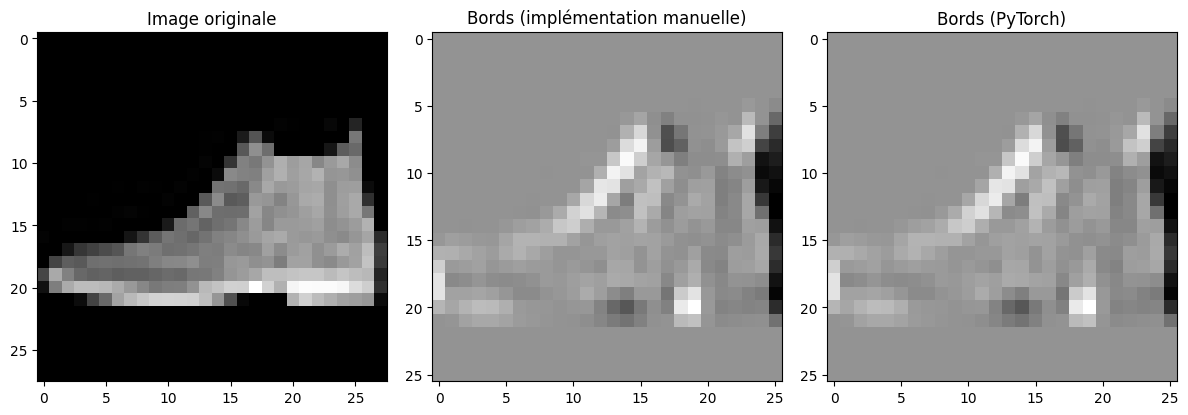

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# ---------------------------------------------------------
# 1. CORRÉLATION CROISÉE 2D FROM SCRATCH
# ---------------------------------------------------------
def cross_correlation_2d_manual(input_tensor, kernel):
    """
    Implémentation manuelle de la corrélation 2D (sans retournement du kernel).
    
    Args:
        input_tensor: tenseur de shape (batch_size, in_channels, H, W)
        kernel: filtre de shape (out_channels, in_channels, kH, kW)
    
    Returns:
        output: tenseur de shape (batch_size, out_channels, H_out, W_out)
    """
    batch_size, in_channels, H, W = input_tensor.shape
    out_channels, _, kH, kW = kernel.shape
    
    # Calcul de la taille de sortie (sans padding, stride=1)
    H_out = H - kH + 1
    W_out = W - kW + 1
    
    # Initialisation de la sortie
    output = torch.zeros(batch_size, out_channels, H_out, W_out)
    
    # Boucle sur chaque position spatiale de sortie
    for i in range(H_out):
        for j in range(W_out):
            # Extraction de la fenêtre courante
            window = input_tensor[:, :, i:i+kH, j:j+kW]  # (batch, in_channels, kH, kW)
            
            # Produit élément-wise + somme sur tous les canaux et positions du kernel
            # window.unsqueeze(1) → (batch, 1, in_channels, kH, kW)
            # kernel → (out_channels, in_channels, kH, kW)
            # Résultat: (batch, out_channels)
            output[:, :, i, j] = (window.unsqueeze(1) * kernel).sum(dim=(2, 3, 4))
    
    return output

# ---------------------------------------------------------
# 2. MAX-POOLING & AVERAGE-POOLING FROM SCRATCH
# ---------------------------------------------------------
def max_pool_2d_manual(input_tensor, kernel_size=2, stride=2):
    """
    Implémentation manuelle du max-pooling 2D.
    """
    batch_size, channels, H, W = input_tensor.shape
    kH, kW = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
    sH, sW = stride if isinstance(stride, tuple) else (stride, stride)
    
    H_out = (H - kH) // sH + 1
    W_out = (W - kW) // sW + 1
    
    output = torch.zeros(batch_size, channels, H_out, W_out)
    
    for i in range(H_out):
        for j in range(W_out):
            window = input_tensor[:, :, i*sH:i*sH+kH, j*sW:j*sW+kW]
            output[:, :, i, j] = window.max(dim=3)[0].max(dim=2)[0]
    
    return output

def avg_pool_2d_manual(input_tensor, kernel_size=2, stride=2):
    """
    Implémentation manuelle de l'average-pooling 2D.
    """
    batch_size, channels, H, W = input_tensor.shape
    kH, kW = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
    sH, sW = stride if isinstance(stride, tuple) else (stride, stride)
    
    H_out = (H - kH) // sH + 1
    W_out = (W - kW) // sW + 1
    
    output = torch.zeros(batch_size, channels, H_out, W_out)
    
    for i in range(H_out):
        for j in range(W_out):
            window = input_tensor[:, :, i*sH:i*sH+kH, j*sW:j*sW+kW]
            output[:, :, i, j] = window.mean(dim=(2, 3))
    
    return output

# ---------------------------------------------------------
# 3. TEST & COMPARAISON AVEC PYTORCH
# ---------------------------------------------------------
print("🧪 TEST DES IMPLÉMENTATIONS MANUELLES\n")

# Données de test: batch de 2 images 6x6 avec 1 canal
torch.manual_seed(42)
test_input = torch.randn(2, 1, 6, 6)
print(f"Input shape: {test_input.shape}")

# --- Test Corrélation 2D ---
print("\n--- Test Corrélation 2D ---")
kernel_manual = torch.randn(1, 1, 3, 3)  # 1 filtre 3x3

# Version manuelle
output_manual = cross_correlation_2d_manual(test_input, kernel_manual)

# Version PyTorch (nn.Conv2d sans biais pour comparer)
conv_pytorch = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, bias=False)
conv_pytorch.weight.data = kernel_manual  # Même kernel
output_pytorch = conv_pytorch(test_input)

print(f"Output manuel shape: {output_manual.shape}")
print(f"Output PyTorch shape: {output_pytorch.shape}")
print(f"✅ Corrélation 2D: {'IDENTIQUES' if torch.allclose(output_manual, output_pytorch, atol=1e-6) else 'DIFFÉRENTES'}")
if not torch.allclose(output_manual, output_pytorch, atol=1e-6):
    print(f"   Différence max: {(output_manual - output_pytorch).abs().max().item():.2e}")

# --- Test Max-Pooling ---
print("\n--- Test Max-Pooling 2x2 ---")
output_max_manual = max_pool_2d_manual(test_input, kernel_size=2, stride=2)
output_max_pytorch = F.max_pool2d(test_input, kernel_size=2, stride=2)

print(f"Output manuel shape: {output_max_manual.shape}")
print(f"Output PyTorch shape: {output_max_pytorch.shape}")
print(f"✅ Max-Pooling: {'IDENTIQUES' if torch.allclose(output_max_manual, output_max_pytorch, atol=1e-6) else 'DIFFÉRENTES'}")

# --- Test Average-Pooling ---
print("\n--- Test Average-Pooling 2x2 ---")
output_avg_manual = avg_pool_2d_manual(test_input, kernel_size=2, stride=2)
output_avg_pytorch = F.avg_pool2d(test_input, kernel_size=2, stride=2)

print(f"Output manuel shape: {output_avg_manual.shape}")
print(f"Output PyTorch shape: {output_avg_pytorch.shape}")
print(f"✅ Average-Pooling: {'IDENTIQUES' if torch.allclose(output_avg_manual, output_avg_pytorch, atol=1e-6) else 'DIFFÉRENTES'}")

# ---------------------------------------------------------
# 4. VISUALISATION SUR UNE IMAGE RÉELLE DU DATASET
# ---------------------------------------------------------
print("\n📸 APPLICATION SUR UNE IMAGE FASHION-MNIST")

# Récupérer une image du dataset
sample_image, sample_label = test_set[0]  # Shape: (1, 28, 28)
sample_image = sample_image.unsqueeze(0)  # Ajouter batch dimension: (1, 1, 28, 28)

# Appliquer un filtre de détection de bords manuel (Sobel-like)
sobel_x = torch.tensor([[[-1, 0, 1],
                         [-2, 0, 2],
                         [-1, 0, 1]]], dtype=torch.float32).unsqueeze(0)  # (1, 1, 3, 3)

edges_manual = cross_correlation_2d_manual(sample_image, sobel_x)
edges_pytorch = F.conv2d(sample_image, sobel_x)

print(f"Image originale: {sample_image.shape}")
print(f"Bords détectés (manuel): {edges_manual.shape}")
print(f"Bords détectés (PyTorch): {edges_pytorch.shape}")
print(f"✅ Détection de bords: {'VALIDÉE' if torch.allclose(edges_manual, edges_pytorch, atol=1e-6) else 'ERREUR'}")

# Afficher les résultats
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(sample_image[0, 0], cmap='gray')
axes[0].set_title("Image originale")
axes[1].imshow(edges_manual[0, 0], cmap='gray')
axes[1].set_title("Bords (implémentation manuelle)")
axes[2].imshow(edges_pytorch[0, 0], cmap='gray')
axes[2].set_title("Bords (PyTorch)")
plt.tight_layout()
plt.show()

✅ Dossiers créés dans: part2_results
🔍 VISUALISATION DES FEATURE MAPS
📸 Affichage des Feature Maps (Couche 1 - 6 filtres)
💾 Sauvegardé : part2_results\figures\feature_maps_conv1.png


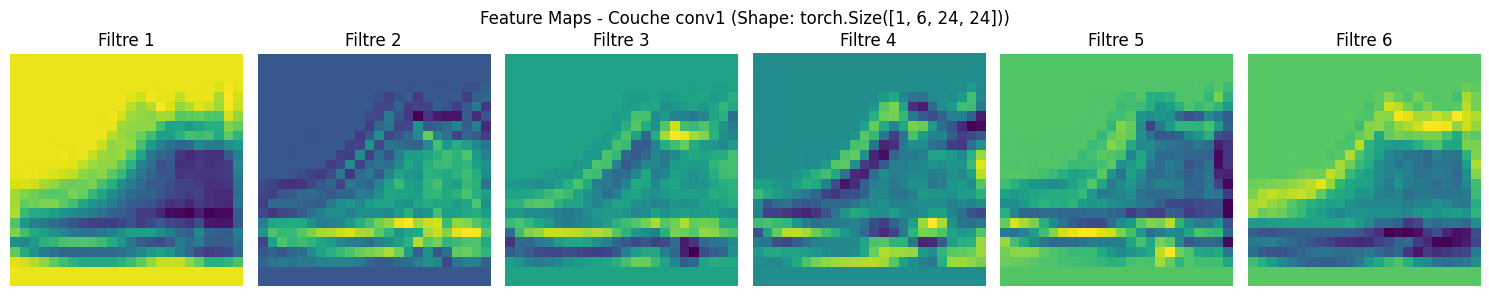

📸 Affichage des Feature Maps (Couche 2 - 16 filtres)
💾 Sauvegardé : part2_results\figures\feature_maps_conv2.png


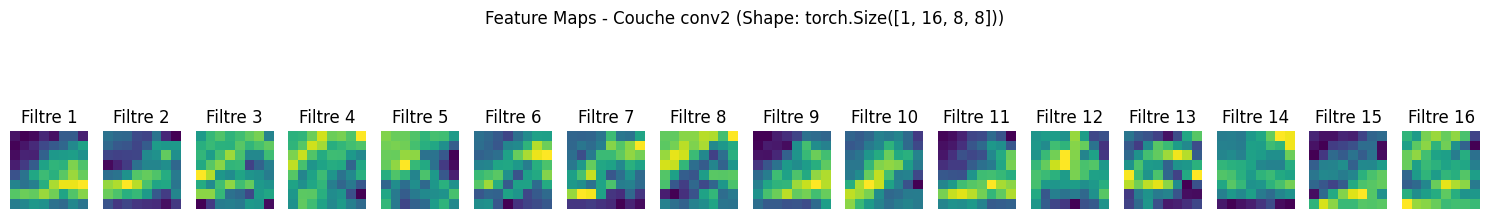

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import os
from pathlib import Path

# 1. Création des dossiers pour la Partie 2 (CORRIGÉ)
RESULTS_DIR_P2 = Path("part2_results")
RESULTS_DIR_P2.mkdir(parents=True, exist_ok=True)  # ← Crée le dossier parent
(RESULTS_DIR_P2 / "figures").mkdir(exist_ok=True)  # ← Puis le sous-dossier

print(f"✅ Dossiers créés dans: {RESULTS_DIR_P2}")

# ---------------------------------------------------------
# 2. DÉFINITION DU MODÈLE CNN (LeNet)
# ---------------------------------------------------------
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        # Couche 1 : Convolution + Pooling
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Couche 2 : Convolution + Pooling
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Couches Fully Connected
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        
        # Dictionnaire pour stocker les activations
        self.activations = {}
        
        # Hooks
        self.conv1.register_forward_hook(self._get_activation('conv1'))
        self.conv2.register_forward_hook(self._get_activation('conv2'))

    def _get_activation(self, name):
        def hook(model, input, output):
            self.activations[name] = output.detach()
        return hook

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# ---------------------------------------------------------
# 3. DÉFINITION DU MLP (Pour comparaison)
# ---------------------------------------------------------
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        
    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# ---------------------------------------------------------
# 4. VISUALISATION DES FEATURE MAPS
# ---------------------------------------------------------
print("🔍 VISUALISATION DES FEATURE MAPS")

model = LeNet()
model.eval()

sample_img, sample_label = test_set[0]
sample_img = sample_img.unsqueeze(0)

with torch.no_grad():
    output = model(sample_img)

def plot_feature_maps(activations_dict, layer_name):
    maps = activations_dict[layer_name]
    num_filters = maps.shape[1]
    
    fig, axes = plt.subplots(1, num_filters, figsize=(15, 3))
    if num_filters == 1:
        axes = [axes]
        
    for i, ax in enumerate(axes):
        ax.imshow(maps[0, i].numpy(), cmap='viridis')
        ax.axis('off')
        ax.set_title(f"Filtre {i+1}")
    
    plt.suptitle(f"Feature Maps - Couche {layer_name} (Shape: {maps.shape})")
    plt.tight_layout()
    
    save_path = RESULTS_DIR_P2 / "figures" / f"feature_maps_{layer_name}.png"
    fig.savefig(save_path)
    print(f"💾 Sauvegardé : {save_path}")
    plt.show()

print("📸 Affichage des Feature Maps (Couche 1 - 6 filtres)")
plot_feature_maps(model.activations, 'conv1')

print("📸 Affichage des Feature Maps (Couche 2 - 16 filtres)")
plot_feature_maps(model.activations, 'conv2')

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Assurez-vous que les classes LeNet et SimpleMLP sont déjà définies

# ---------------------------------------------------------
# 1. FONCTION D'ENTRAÎNEMENT GÉNÉRIQUE
# ---------------------------------------------------------
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3, device="cpu"):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    
    for epoch in range(epochs):
        # Phase d'entraînement
        model.train()
        t_loss, t_correct, t_total = 0, 0, 0
        
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            t_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            t_correct += predicted.eq(labels).sum().item()
            t_total += labels.size(0)
        
        # Phase de validation
        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                v_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                v_correct += predicted.eq(labels).sum().item()
                v_total += labels.size(0)
        
        history["train_loss"].append(t_loss / t_total)
        history["train_acc"].append(t_correct / t_total)
        history["val_loss"].append(v_loss / v_total)
        history["val_acc"].append(v_correct / v_total)
        
        print(f"Epoch {epoch+1}: Train Loss={t_loss/t_total:.4f}, "
              f"Train Acc={t_correct/t_total:.4f}, Val Acc={v_correct/v_total:.4f}")
    
    return history, model

# ---------------------------------------------------------
# 2. COMPARAISON MLP vs CNN
# ---------------------------------------------------------
print("🔬 COMPARAISON MLP vs CNN\n")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Initialiser les modèles
mlp_model = SimpleMLP()
cnn_model = LeNet()

# Entraîner le MLP
print("\n📊 Entraînement du MLP...")
mlp_history, mlp_trained = train_model(mlp_model, train_loader, val_loader, epochs=5, lr=1e-3, device=device)

# Entraîner le CNN
print("\n📊 Entraînement du CNN (LeNet)...")
cnn_history, cnn_trained = train_model(cnn_model, train_loader, val_loader, epochs=5, lr=1e-3, device=device)

# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(mlp_history["train_acc"], label="MLP Train", linestyle="--")
axes[0].plot(mlp_history["val_acc"], label="MLP Val")
axes[0].plot(cnn_history["train_acc"], label="CNN Train", linestyle="--")
axes[0].plot(cnn_history["val_acc"], label="CNN Val")
axes[0].set_title("Accuracy - MLP vs CNN")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(mlp_history["train_loss"], label="MLP Train", linestyle="--")
axes[1].plot(mlp_history["val_loss"], label="MLP Val")
axes[1].plot(cnn_history["train_loss"], label="CNN Train", linestyle="--")
axes[1].plot(cnn_history["val_loss"], label="CNN Val")
axes[1].set_title("Loss - MLP vs CNN")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(RESULTS_DIR_P2 / "figures" / "mlp_vs_cnn_comparison.png")
print(f"💾 Comparaison sauvegardée: {RESULTS_DIR_P2 / 'figures' / 'mlp_vs_cnn_comparison.png'}")
plt.show()

print(f"\n✅ Résultats finaux:")
print(f"   MLP - Val Accuracy: {mlp_history['val_acc'][-1]:.4f}")
print(f"   CNN - Val Accuracy: {cnn_history['val_acc'][-1]:.4f}")
print(f"   Gain CNN vs MLP: {((cnn_history['val_acc'][-1] / mlp_history['val_acc'][-1]) - 1) * 100:.1f}%")

# ---------------------------------------------------------
# 3. ÉTUDE DE L'INFLUENCE DES HYPERPARAMÈTRES
# ---------------------------------------------------------
print("\n🔧 ÉTUDE DE L'INFLUENCE DES HYPERPARAMÈTRES\n")

# Définition de 5 variantes architecturales
class CNN_Variant1(nn.Module):
    """Avec padding pour préserver la résolution"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)  # padding=2 garde 28x28
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, padding=2)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 7 * 7, 120)  # 28/4 = 7
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    
    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class CNN_Variant2(nn.Module):
    """Avec stride=2 au lieu de pooling"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=2)  # stride=2 réduit directement
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=2)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)  # 28 -> 12 -> 4
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class CNN_Variant3(nn.Module):
    """Average pooling au lieu de max pooling"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.pool1 = nn.AvgPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.pool2 = nn.AvgPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    
    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class CNN_Variant4(nn.Module):
    """Plus de filtres (capacité accrue)"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5)  # 16 au lieu de 6
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5)  # 32 au lieu de 16
        self.pool2 = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    
    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class CNN_Variant5(nn.Module):
    """Avec convolution 1x1 (réduction de canaux)"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv1x1 = nn.Conv2d(6, 4, kernel_size=1)  # Réduction de 6 à 4 canaux
        self.conv2 = nn.Conv2d(4, 16, kernel_size=5)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    
    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = F.relu(self.conv1x1(x))  # Conv 1x1
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Tester les 5 variantes (1 epoch rapide pour la comparaison)
variants = {
    "LeNet (baseline)": LeNet(),
    "Avec padding": CNN_Variant1(),
    "Stride=2 (no pooling)": CNN_Variant2(),
    "Average pooling": CNN_Variant3(),
    "Plus de filtres": CNN_Variant4(),
    "Conv 1x1": CNN_Variant5()
}

results = []

print("🚀 Test des variantes architecturales (1 epoch rapide)...\n")

for name, model in variants.items():
    print(f"📊 Test: {name}")
    history, _ = train_model(model, train_loader, val_loader, epochs=1, lr=1e-3, device=device)
    val_acc = history["val_acc"][-1]
    val_loss = history["val_loss"][-1]
    
    # Compter les paramètres
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    results.append({
        "Modèle": name,
        "Val Accuracy": val_acc,
        "Val Loss": val_loss,
        "Paramètres": num_params
    })
    print(f"   Val Acc: {val_acc:.4f} | Params: {num_params:,}\n")

# Tableau comparatif
df_results = pd.DataFrame(results)
print("\n" + "="*80)
print("📋 TABLEAU COMPARATIF DES VARIANTES")
print("="*80)
print(df_results.to_string(index=False))
print("="*80)

# Sauvegarde
df_results.to_csv(RESULTS_DIR_P2 / "architectural_variants_comparison.csv", index=False)
print(f"💾 Résultats sauvegardés: {RESULTS_DIR_P2 / 'architectural_variants_comparison.csv'}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].barh(df_results["Modèle"], df_results["Val Accuracy"], color='steelblue')
axes[0].set_xlabel("Validation Accuracy")
axes[0].set_title("Performance des Variantes Architecturales")
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(df_results["Modèle"], df_results["Paramètres"], color='coral')
axes[1].set_xlabel("Nombre de Paramètres")
axes[1].set_title("Complexité des Modèles")
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR_P2 / "figures" / "architectural_variants.png")
print(f"💾 Graphique sauvegardé: {RESULTS_DIR_P2 / 'figures' / 'architectural_variants.png'}")
plt.show()

ModuleNotFoundError: No module named 'tqdm'

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Assurez-vous que les classes LeNet et SimpleMLP sont déjà définies

# ---------------------------------------------------------
# 1. FONCTION D'ENTRAÎNEMENT GÉNÉRIQUE (SANS tqdm)
# ---------------------------------------------------------
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3, device="cpu"):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    
    for epoch in range(epochs):
        # Phase d'entraînement
        model.train()
        t_loss, t_correct, t_total = 0, 0, 0
        
        # MODIFICATION: boucle simple sans tqdm
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            t_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            t_correct += predicted.eq(labels).sum().item()
            t_total += labels.size(0)
        
        # Phase de validation
        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                v_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                v_correct += predicted.eq(labels).sum().item()
                v_total += labels.size(0)
        
        history["train_loss"].append(t_loss / t_total)
        history["train_acc"].append(t_correct / t_total)
        history["val_loss"].append(v_loss / v_total)
        history["val_acc"].append(v_correct / v_total)
        
        print(f"Epoch {epoch+1}: Train Loss={t_loss/t_total:.4f}, "
              f"Train Acc={t_correct/t_total:.4f}, Val Acc={v_correct/v_total:.4f}")
    
    return history, model

# ---------------------------------------------------------
# 2. COMPARAISON MLP vs CNN
# ---------------------------------------------------------
print("🔬 COMPARAISON MLP vs CNN\n")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Initialiser les modèles
mlp_model = SimpleMLP()
cnn_model = LeNet()

# Entraîner le MLP
print("\n📊 Entraînement du MLP...")
mlp_history, mlp_trained = train_model(mlp_model, train_loader, val_loader, epochs=5, lr=1e-3, device=device)

# Entraîner le CNN
print("\n📊 Entraînement du CNN (LeNet)...")
cnn_history, cnn_trained = train_model(cnn_model, train_loader, val_loader, epochs=5, lr=1e-3, device=device)

# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(mlp_history["train_acc"], label="MLP Train", linestyle="--")
axes[0].plot(mlp_history["val_acc"], label="MLP Val")
axes[0].plot(cnn_history["train_acc"], label="CNN Train", linestyle="--")
axes[0].plot(cnn_history["val_acc"], label="CNN Val")
axes[0].set_title("Accuracy - MLP vs CNN")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(mlp_history["train_loss"], label="MLP Train", linestyle="--")
axes[1].plot(mlp_history["val_loss"], label="MLP Val")
axes[1].plot(cnn_history["train_loss"], label="CNN Train", linestyle="--")
axes[1].plot(cnn_history["val_loss"], label="CNN Val")
axes[1].set_title("Loss - MLP vs CNN")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(RESULTS_DIR_P2 / "figures" / "mlp_vs_cnn_comparison.png")
print(f"💾 Comparaison sauvegardée: {RESULTS_DIR_P2 / 'figures' / 'mlp_vs_cnn_comparison.png'}")
plt.show()

print(f"\n✅ Résultats finaux:")
print(f"   MLP - Val Accuracy: {mlp_history['val_acc'][-1]:.4f}")
print(f"   CNN - Val Accuracy: {cnn_history['val_acc'][-1]:.4f}")
print(f"   Gain CNN vs MLP: {((cnn_history['val_acc'][-1] / mlp_history['val_acc'][-1]) - 1) * 100:.1f}%")

# ---------------------------------------------------------
# 3. ÉTUDE DE L'INFLUENCE DES HYPERPARAMÈTRES
# ---------------------------------------------------------
print("\n🔧 ÉTUDE DE L'INFLUENCE DES HYPERPARAMÈTRES\n")

# Définition de 5 variantes architecturales
class CNN_Variant1(nn.Module):
    """Avec padding pour préserver la résolution"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)  # padding=2 garde 28x28
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, padding=2)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 7 * 7, 120)  # 28/4 = 7
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    
    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class CNN_Variant2(nn.Module):
    """Avec stride=2 au lieu de pooling"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=2)  # stride=2 réduit directement
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=2)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)  # 28 -> 12 -> 4
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class CNN_Variant3(nn.Module):
    """Average pooling au lieu de max pooling"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.pool1 = nn.AvgPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.pool2 = nn.AvgPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    
    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class CNN_Variant4(nn.Module):
    """Plus de filtres (capacité accrue)"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5)  # 16 au lieu de 6
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5)  # 32 au lieu de 16
        self.pool2 = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    
    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class CNN_Variant5(nn.Module):
    """Avec convolution 1x1 (réduction de canaux)"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv1x1 = nn.Conv2d(6, 4, kernel_size=1)  # Réduction de 6 à 4 canaux
        self.conv2 = nn.Conv2d(4, 16, kernel_size=5)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    
    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = F.relu(self.conv1x1(x))  # Conv 1x1
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Tester les 5 variantes (1 epoch rapide pour la comparaison)
variants = {
    "LeNet (baseline)": LeNet(),
    "Avec padding": CNN_Variant1(),
    "Stride=2 (no pooling)": CNN_Variant2(),
    "Average pooling": CNN_Variant3(),
    "Plus de filtres": CNN_Variant4(),
    "Conv 1x1": CNN_Variant5()
}

results = []

print("🚀 Test des variantes architecturales (1 epoch rapide)...\n")

for name, model in variants.items():
    print(f"📊 Test: {name}")
    history, _ = train_model(model, train_loader, val_loader, epochs=1, lr=1e-3, device=device)
    val_acc = history["val_acc"][-1]
    val_loss = history["val_loss"][-1]
    
    # Compter les paramètres
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    results.append({
        "Modèle": name,
        "Val Accuracy": val_acc,
        "Val Loss": val_loss,
        "Paramètres": num_params
    })
    print(f"   Val Acc: {val_acc:.4f} | Params: {num_params:,}\n")

# Tableau comparatif
df_results = pd.DataFrame(results)
print("\n" + "="*80)
print("📋 TABLEAU COMPARATIF DES VARIANTES")
print("="*80)
print(df_results.to_string(index=False))
print("="*80)

# Sauvegarde
df_results.to_csv(RESULTS_DIR_P2 / "architectural_variants_comparison.csv", index=False)
print(f"💾 Résultats sauvegardés: {RESULTS_DIR_P2 / 'architectural_variants_comparison.csv'}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].barh(df_results["Modèle"], df_results["Val Accuracy"], color='steelblue')
axes[0].set_xlabel("Validation Accuracy")
axes[0].set_title("Performance des Variantes Architecturales")
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(df_results["Modèle"], df_results["Paramètres"], color='coral')
axes[1].set_xlabel("Nombre de Paramètres")
axes[1].set_title("Complexité des Modèles")
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR_P2 / "figures" / "architectural_variants.png")
print(f"💾 Graphique sauvegardé: {RESULTS_DIR_P2 / 'figures' / 'architectural_variants.png'}")
plt.show()

🔬 COMPARAISON MLP vs CNN

Device: cpu

 Entraînement du MLP...
Epoch 1: Train Loss=0.5265, Train Acc=0.8126, Val Acc=0.8529
Epoch 2: Train Loss=0.3698, Train Acc=0.8651, Val Acc=0.8631
Epoch 3: Train Loss=0.3291, Train Acc=0.8804, Val Acc=0.8766
Epoch 4: Train Loss=0.3054, Train Acc=0.8856, Val Acc=0.8689
Epoch 5: Train Loss=0.2899, Train Acc=0.8924, Val Acc=0.8761

📊 Entraînement du CNN (LeNet)...
Epoch 1: Train Loss=0.7308, Train Acc=0.7271, Val Acc=0.7951
Epoch 2: Train Loss=0.4603, Train Acc=0.8266, Val Acc=0.8373
Epoch 3: Train Loss=0.3975, Train Acc=0.8512, Val Acc=0.8554
Epoch 4: Train Loss=0.3558, Train Acc=0.8685, Val Acc=0.8642
Epoch 5: Train Loss=0.3328, Train Acc=0.8774, Val Acc=0.8766
💾 Comparaison sauvegardée: part2_results\figures\mlp_vs_cnn_comparison.png


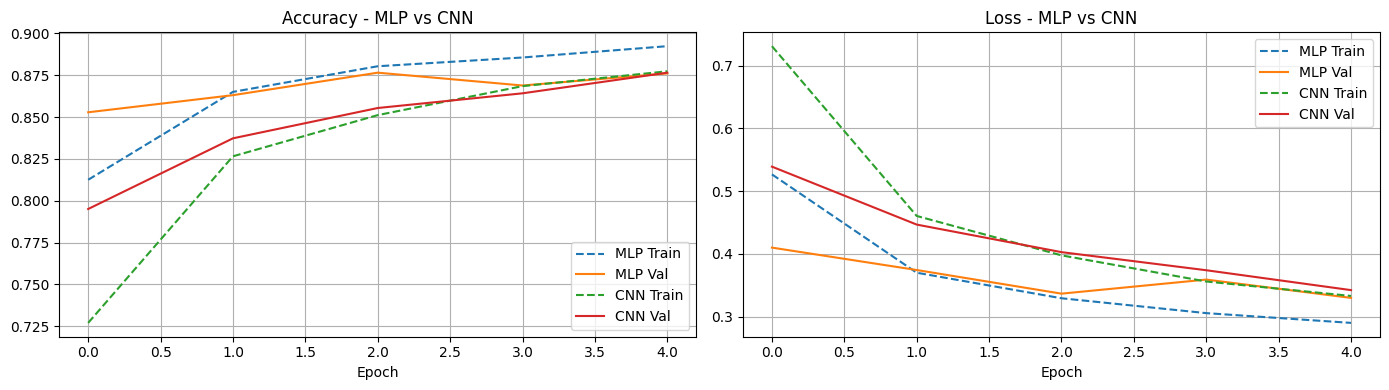


✅ Résultats finaux:
   MLP - Val Accuracy: 0.8761
   CNN - Val Accuracy: 0.8766
   Gain CNN vs MLP: 0.1%

🔧 ÉTUDE DE L'INFLUENCE DES HYPERPARAMÈTRES

🚀 Test des variantes architecturales (1 epoch rapide)...

📊 Test: LeNet (baseline)
Epoch 1: Train Loss=0.7057, Train Acc=0.7461, Val Acc=0.8199
   Val Acc: 0.8199 | Params: 44,426

📊 Test: Avec padding
Epoch 1: Train Loss=0.7023, Train Acc=0.7390, Val Acc=0.8298
   Val Acc: 0.8298 | Params: 107,786

📊 Test: Stride=2 (no pooling)
Epoch 1: Train Loss=0.7392, Train Acc=0.7255, Val Acc=0.8097
   Val Acc: 0.8097 | Params: 44,426

📊 Test: Average pooling
Epoch 1: Train Loss=0.7974, Train Acc=0.7010, Val Acc=0.7604
   Val Acc: 0.7604 | Params: 44,426

📊 Test: Plus de filtres
Epoch 1: Train Loss=0.6362, Train Acc=0.7649, Val Acc=0.8398
   Val Acc: 0.8398 | Params: 85,822

📊 Test: Conv 1x1
Epoch 1: Train Loss=0.8463, Train Acc=0.6821, Val Acc=0.7666
   Val Acc: 0.7666 | Params: 43,654


📋 TABLEAU COMPARATIF DES VARIANTES
               Modèle  Va

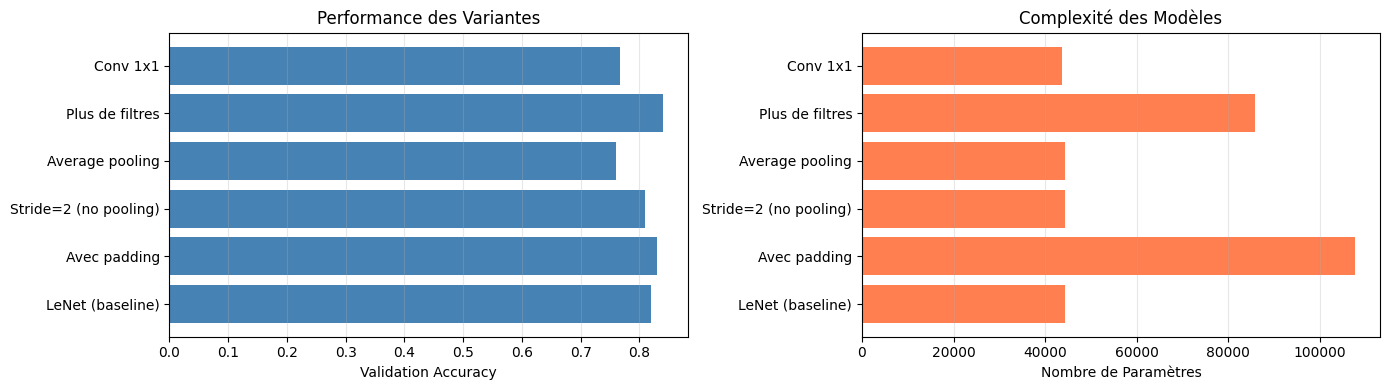

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ---------------------------------------------------------
# 1. FONCTION D'ENTRAÎNEMENT GÉNÉRIQUE
# ---------------------------------------------------------
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3, device="cpu"):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    
    for epoch in range(epochs):
        # Phase d'entraînement
        model.train()
        t_loss, t_correct, t_total = 0, 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            t_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            t_correct += predicted.eq(labels).sum().item()
            t_total += labels.size(0)
        
        # Phase de validation
        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                v_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                v_correct += predicted.eq(labels).sum().item()
                v_total += labels.size(0)
        
        history["train_loss"].append(t_loss / t_total)
        history["train_acc"].append(t_correct / t_total)
        history["val_loss"].append(v_loss / v_total)
        history["val_acc"].append(v_correct / v_total)
        
        print(f"Epoch {epoch+1}: Train Loss={t_loss/t_total:.4f}, "
              f"Train Acc={t_correct/t_total:.4f}, Val Acc={v_correct/v_total:.4f}")
    
    return history, model

# ---------------------------------------------------------
# 2. COMPARAISON MLP vs CNN
# ---------------------------------------------------------
print("🔬 COMPARAISON MLP vs CNN\n")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Instanciation des modèles (définis dans la cellule précédente)
mlp_model = SimpleMLP()
cnn_model = LeNet()

# Entraînement du MLP
print("\n Entraînement du MLP...")
mlp_history, mlp_trained = train_model(mlp_model, train_loader, val_loader, epochs=5, lr=1e-3, device=device)

# Entraînement du CNN
print("\n📊 Entraînement du CNN (LeNet)...")
cnn_history, cnn_trained = train_model(cnn_model, train_loader, val_loader, epochs=5, lr=1e-3, device=device)

# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(mlp_history["train_acc"], label="MLP Train", linestyle="--")
axes[0].plot(mlp_history["val_acc"], label="MLP Val")
axes[0].plot(cnn_history["train_acc"], label="CNN Train", linestyle="--")
axes[0].plot(cnn_history["val_acc"], label="CNN Val")
axes[0].set_title("Accuracy - MLP vs CNN")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(mlp_history["train_loss"], label="MLP Train", linestyle="--")
axes[1].plot(mlp_history["val_loss"], label="MLP Val")
axes[1].plot(cnn_history["train_loss"], label="CNN Train", linestyle="--")
axes[1].plot(cnn_history["val_loss"], label="CNN Val")
axes[1].set_title("Loss - MLP vs CNN")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(RESULTS_DIR_P2 / "figures" / "mlp_vs_cnn_comparison.png")
print(f"💾 Comparaison sauvegardée: {RESULTS_DIR_P2 / 'figures' / 'mlp_vs_cnn_comparison.png'}")
plt.show()

print(f"\n✅ Résultats finaux:")
print(f"   MLP - Val Accuracy: {mlp_history['val_acc'][-1]:.4f}")
print(f"   CNN - Val Accuracy: {cnn_history['val_acc'][-1]:.4f}")
print(f"   Gain CNN vs MLP: {((cnn_history['val_acc'][-1] / mlp_history['val_acc'][-1]) - 1) * 100:.1f}%")

# ---------------------------------------------------------
# 3. ÉTUDE DE L'INFLUENCE DES HYPERPARAMÈTRES
# ---------------------------------------------------------
print("\n🔧 ÉTUDE DE L'INFLUENCE DES HYPERPARAMÈTRES\n")

# Variantes architecturales
class CNN_Variant1(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, padding=2)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 7 * 7, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class CNN_Variant2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=2)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class CNN_Variant3(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.pool1 = nn.AvgPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.pool2 = nn.AvgPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class CNN_Variant4(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class CNN_Variant5(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv1x1 = nn.Conv2d(6, 4, kernel_size=1)
        self.conv2 = nn.Conv2d(4, 16, kernel_size=5)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = F.relu(self.conv1x1(x))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Dictionnaire des variantes
variants = {
    "LeNet (baseline)": LeNet(),
    "Avec padding": CNN_Variant1(),
    "Stride=2 (no pooling)": CNN_Variant2(),
    "Average pooling": CNN_Variant3(),
    "Plus de filtres": CNN_Variant4(),
    "Conv 1x1": CNN_Variant5()
}

results = []
print("🚀 Test des variantes architecturales (1 epoch rapide)...\n")

for name, model in variants.items():
    print(f"📊 Test: {name}")
    history, _ = train_model(model, train_loader, val_loader, epochs=1, lr=1e-3, device=device)
    val_acc = history["val_acc"][-1]
    val_loss = history["val_loss"][-1]
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    results.append({
        "Modèle": name,
        "Val Accuracy": val_acc,
        "Val Loss": val_loss,
        "Paramètres": num_params
    })
    print(f"   Val Acc: {val_acc:.4f} | Params: {num_params:,}\n")

# Tableau & visualisation
df_results = pd.DataFrame(results)
print("\n" + "="*80)
print("📋 TABLEAU COMPARATIF DES VARIANTES")
print("="*80)
print(df_results.to_string(index=False))
print("="*80)

df_results.to_csv(RESULTS_DIR_P2 / "architectural_variants_comparison.csv", index=False)
print(f"💾 CSV sauvegardé: {RESULTS_DIR_P2 / 'architectural_variants_comparison.csv'}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].barh(df_results["Modèle"], df_results["Val Accuracy"], color='steelblue')
axes[0].set_xlabel("Validation Accuracy")
axes[0].set_title("Performance des Variantes")
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(df_results["Modèle"], df_results["Paramètres"], color='coral')
axes[1].set_xlabel("Nombre de Paramètres")
axes[1].set_title("Complexité des Modèles")
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR_P2 / "figures" / "architectural_variants.png")
print(f"💾 Graphique sauvegardé: {RESULTS_DIR_P2 / 'figures' / 'architectural_variants.png'}")
plt.show()